Merged dataset: 95 rows (removed 0 invalid rows)
      Subjective     Objective  Spearman_rho  p_value
0            SUS    T_task_sec        -0.539   0.0000
1            SUS        N_cmds        -0.185   0.0722
2            SUS  avg_cmd_time        -0.362   0.0003
3            TPA    T_task_sec        -0.549   0.0000
4            TPA        N_cmds        -0.232   0.0239
5            TPA  avg_cmd_time        -0.332   0.0010
6            TAM    T_task_sec        -0.477   0.0000
7            TAM        N_cmds        -0.282   0.0056
8            TAM  avg_cmd_time        -0.274   0.0072
9   NASA_Overall    T_task_sec         0.397   0.0001
10  NASA_Overall        N_cmds         0.177   0.0855
11  NASA_Overall  avg_cmd_time         0.227   0.0267


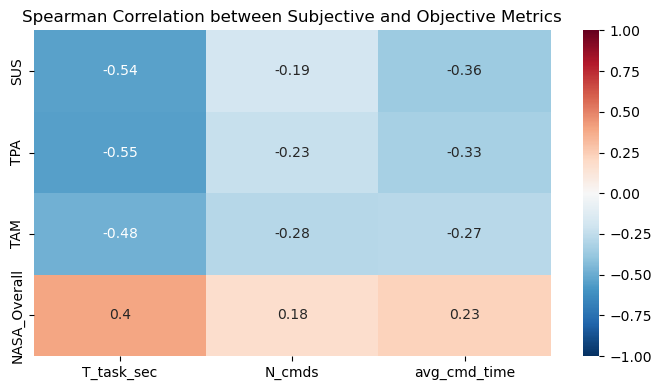

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Robust Correlation Analysis (with type mismatch and NaN handling)
-------------------------------------------------------------
対象:
  ./data/survay.csv        → 主観評価
  ./data/quantitative.csv  → 客観評価
出力:
  - ./results/spearman_corr.csv
  - ./results/corr_heatmap.png
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os

# ====== ファイル読み込み ======
df_subj = pd.read_csv("./data/survay.csv")
df_obj  = pd.read_csv("./data/quantitative.csv")

# ====== キー列の型を揃える ======
# participant は全て「文字列」に統一する
df_subj["participant"] = df_subj["participant"].astype(str).str.replace("P", "", regex=False).astype(int)
df_obj["participant"]  = df_obj["participant"].astype(int)

# condition 名も同じフォーマットに統一（空白などがある場合対策）
df_subj["condition"] = df_subj["condition"].str.strip()
df_obj["condition"]  = df_obj["condition"].str.strip()

# ====== データ結合 ======
df = pd.merge(df_subj, df_obj, on=["participant", "condition"], how="inner")

# ====== 欠損・異常行を除外 ======
before = len(df)
df = df.dropna(subset=["SUS", "T_task_sec"])  # 主観 or 客観が欠損している行を除く
after = len(df)
print(f"Merged dataset: {after} rows (removed {before - after} invalid rows)")

# ====== 対象列 ======
subjective_vars = ["SUS", "TPA", "TAM", "NASA_Overall"]
objective_vars = ["T_task_sec", "N_cmds", "avg_cmd_time"]

# ====== Spearman 相関計算 ======
results = []
for s_var in subjective_vars:
    for o_var in objective_vars:
        if s_var in df.columns and o_var in df.columns:
            rho, p = spearmanr(df[s_var], df[o_var], nan_policy="omit")
            results.append({
                "Subjective": s_var,
                "Objective": o_var,
                "Spearman_rho": round(rho, 3),
                "p_value": round(p, 4)
            })

result_df = pd.DataFrame(results)
os.makedirs("./results", exist_ok=True)
result_df.to_csv("./results/spearman_corr.csv", index=False)
print(result_df)

# ====== ヒートマップ作成 ======
corr_matrix = pd.DataFrame(index=subjective_vars, columns=objective_vars, dtype=float)
for s_var in subjective_vars:
    for o_var in objective_vars:
        if s_var in df.columns and o_var in df.columns:
            rho, _ = spearmanr(df[s_var], df[o_var], nan_policy="omit")
            corr_matrix.loc[s_var, o_var] = rho

plt.figure(figsize=(7,4))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation between Subjective and Objective Metrics")
plt.tight_layout()
plt.savefig("./results/corr_heatmap.png", dpi=300)
plt.show()


In [12]:
from scipy.stats import spearmanr
import pandas as pd

conditions = df["condition"].unique()
subjective_vars = ["SUS", "TAM", "TPA", "NASA_Overall"]
objective_vars = ["T_task_sec", "N_cmds", "avg_cmd_time"]

rows = []
for cond in conditions:
    sub_df = df[df["condition"] == cond]
    for s_var in subjective_vars:
        for o_var in objective_vars:
            rho, p = spearmanr(sub_df[s_var], sub_df[o_var], nan_policy="omit")
            rows.append([cond, s_var, o_var, round(rho, 3), round(p, 4)])
cond_corr = pd.DataFrame(rows, columns=["Condition", "Subjective", "Objective", "ρ", "p"])

cond_corr.to_csv("./results/conditionwise_correlation.csv", index=False)
cond_corr



,Condition,Subjective,Objective,ρ,p
0,SR,SUS,T_task_sec,0.078,0.7182
1,SR,SUS,N_cmds,-0.129,0.5468
2,SR,SUS,avg_cmd_time,0.178,0.4051
3,SR,TAM,T_task_sec,0.066,0.7585
4,SR,TAM,N_cmds,-0.222,0.2961
5,SR,TAM,avg_cmd_time,0.211,0.3217
6,SR,TPA,T_task_sec,-0.101,0.6371
7,SR,TPA,N_cmds,-0.220,0.3027
8,SR,TPA,avg_cmd_time,0.184,0.3889
9,SR,NASA_Overall,T_task_sec,0.122,0.5706


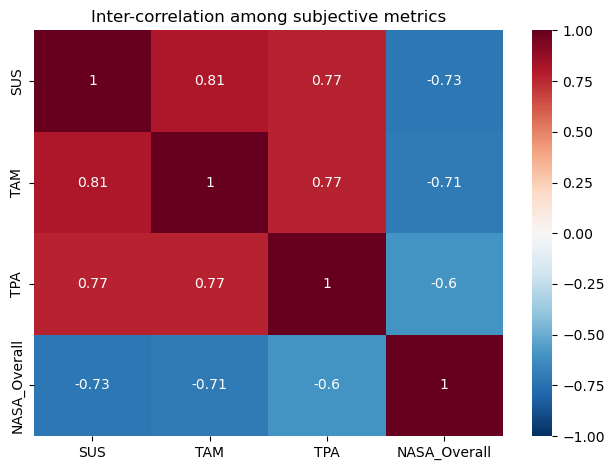

In [13]:
subj_corr = df[["SUS", "TAM", "TPA", "NASA_Overall"]].corr(method="spearman")
sns.heatmap(subj_corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Inter-correlation among subjective metrics")
plt.tight_layout()
plt.savefig("./results/subjective_corr_heatmap.png", dpi=300)
plt.show()
